## LangGraph Concepts & First Graph


In [21]:
from typing import TypedDict


# ─────────────────────────────────────────────────────
# 🔷 ELEMENT 1: STATE
# The State is a SHARED DATA STRUCTURE that holds the
# current information/context of the ENTIRE application.
# Every node reads from it and writes back to it.
# We define it as a TypedDict — a typed Python dictionary.
# ─────────────────────────────────────────────────────
class MyState(TypedDict):
    name: str  # input — who we're greeting
    greeting: str  # output — produced by greet_node
    farewell: str  # output — produced by farewell_node

In [22]:
# ─────────────────────────────────────────────────────
# 🔷 ELEMENT 2: NODES
# Nodes are individual functions that perform specific tasks.
# Two rules:
#   Input  → the full current State dict
#   Output → a dict with ONLY the keys you want to UPDATE
#             (other keys remain unchanged in state)
# ─────────────────────────────────────────────────────
def greet_node(state: MyState) -> dict:
    """Node 1 — Reads name, produces a greeting"""
    greeting = f"Hello, {state['name']}! Welcome to LangGraph. 👋"
    print(f"[greet_node] {greeting}")
    return {"greeting": greeting}  # only 'greeting' is updated


def farewell_node(state: MyState) -> dict:
    """Node 2 — Reads name, produces a farewell"""
    farewell = f"Goodbye, {state['name']}! See you next time. 🙌"
    print(f"[farewell_node] {farewell}")
    return {"farewell": farewell}  # only 'farewell' is updated

In [ ]:
from langgraph.graph import StateGraph, START, END


# ─────────────────────────────────────────────────────
# 🔷 ELEMENT 3: STATEGRAPH
# StateGraph is the class used to BUILD the graph.
# You pass it the State class so it knows the schema.
# ─────────────────────────────────────────────────────
builder = StateGraph(MyState)

# ─────────────────────────────────────────────────────
# Register nodes: builder.add_node("label", function)
# ─────────────────────────────────────────────────────
builder.add_node("greet", greet_node)
builder.add_node("farewell", farewell_node)

# ─────────────────────────────────────────────────────
# 🔷 ELEMENT 4: EDGES
# Edges are CONNECTIONS between nodes that determine
# the flow of execution.  add_edge(from, to)
#
# 🔷 ELEMENT 5: START & END
# START = virtual entry point — where the workflow begins
# END   = conclusion of the workflow
# ─────────────────────────────────────────────────────
# builder.add_edge(START, "greet")  # START → greet
builder.add_edge("greet", "farewell")  # greet → farewell
# builder.add_edge("farewell", END)  # farewell → END

builder.set_entry_point("greet")
builder.set_finish_point("greet")

# ─────────────────────────────────────────────────────
# 🔷 ELEMENT 6: GRAPH (compiled) + RUNNABLE
# .compile() finalises the structure.
# The result is a RUNNABLE — a standardised executable
# component that exposes .invoke(), .stream(), .batch()
# ─────────────────────────────────────────────────────
graph = builder.compile()

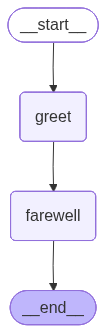

In [67]:
# --- 5. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))
# Diagram: __start__ → greet → farewell → __end__

In [25]:
# --- 6. RUN & TEST ---
result = graph.invoke(
    {
        "name": "Yash",
        "greeting": "",
        "farewell": "",
    }
)
print("\n✅ Final State:")
print(f"  greeting : {result['greeting']}")
print(f"  farewell : {result['farewell']}")
print("\n✅ Complete Result")
print(f"  {result}")

[greet_node] Hello, Yash! Welcome to LangGraph. 👋
[farewell_node] Goodbye, Yash! See you next time. 🙌

✅ Final State:
  greeting : Hello, Yash! Welcome to LangGraph. 👋
  farewell : Goodbye, Yash! See you next time. 🙌

✅ Complete Result
  {'name': 'Yash', 'greeting': 'Hello, Yash! Welcome to LangGraph. 👋', 'farewell': 'Goodbye, Yash! See you next time. 🙌'}
